In [1]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import xgboost

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

import os

/Applications/anaconda3/envs/wids-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
current_dir = os.getcwd()
home_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
data_dir = os.path.join(home_dir, 'data/')

train_cat = pd.read_excel(os.path.join(data_dir, 'TRAIN/TRAIN_CATEGORICAL_METADATA.xlsx'))
train_quant = pd.read_excel(os.path.join(data_dir, 'TRAIN/TRAIN_QUANTITATIVE_METADATA.xlsx'))
train_fcm = pd.read_csv(os.path.join(data_dir, 'TRAIN/TRAIN_FUNCTIONAL_CONNECTOME_MATRICES.csv'))

train_label = pd.read_excel(os.path.join(data_dir, 'TRAIN/TRAINING_SOLUTIONS.xlsx'))

## Data Preprocessing

In [3]:
# Process categorical features
train_cat.isna().sum()

participant_id                       0
Basic_Demos_Enroll_Year              0
Basic_Demos_Study_Site               0
PreInt_Demos_Fam_Child_Ethnicity    11
PreInt_Demos_Fam_Child_Race          0
MRI_Track_Scan_Location              0
Barratt_Barratt_P1_Edu               0
Barratt_Barratt_P1_Occ               0
Barratt_Barratt_P2_Edu               0
Barratt_Barratt_P2_Occ               0
dtype: int64

In [4]:
# fill ethnicity as 3 "Unknown"
train_cat['PreInt_Demos_Fam_Child_Ethnicity'] = train_cat['PreInt_Demos_Fam_Child_Ethnicity'].fillna(3).astype(int)

In [5]:
# create a list for one-hot encoding
for col in train_cat.select_dtypes(include='int').columns:
    train_cat[col] = train_cat[col].astype('category')

columns_to_encode = train_cat.columns[1:].to_list()

len(columns_to_encode)

9

In [6]:
# apply one-hot encoder
encoder = OneHotEncoder(sparse=False, drop='first')

train_cat_encoded = encoder.fit_transform(train_cat[columns_to_encode])
encoded_df = pd.DataFrame(train_cat_encoded, columns=encoder.get_feature_names_out(columns_to_encode))
encoded_df['participant_id'] = train_cat['participant_id']

/Applications/anaconda3/envs/wids-env/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [7]:
# Check quantitative columns
train_quant.isna().sum()

participant_id                  0
EHQ_EHQ_Total                   0
ColorVision_CV_Score            0
APQ_P_APQ_P_CP                  0
APQ_P_APQ_P_ID                  0
APQ_P_APQ_P_INV                 0
APQ_P_APQ_P_OPD                 0
APQ_P_APQ_P_PM                  0
APQ_P_APQ_P_PP                  0
SDQ_SDQ_Conduct_Problems        0
SDQ_SDQ_Difficulties_Total      0
SDQ_SDQ_Emotional_Problems      0
SDQ_SDQ_Externalizing           0
SDQ_SDQ_Generating_Impact       0
SDQ_SDQ_Hyperactivity           0
SDQ_SDQ_Internalizing           0
SDQ_SDQ_Peer_Problems           0
SDQ_SDQ_Prosocial               0
MRI_Track_Age_at_Scan         360
dtype: int64

In [8]:
# fill missing mri track age with median
train_quant['MRI_Track_Age_at_Scan'].fillna(train_quant['MRI_Track_Age_at_Scan'].median(), inplace=True)

In [9]:
train_quant.dtypes

participant_id                 object
EHQ_EHQ_Total                 float64
ColorVision_CV_Score            int64
APQ_P_APQ_P_CP                  int64
APQ_P_APQ_P_ID                  int64
APQ_P_APQ_P_INV                 int64
APQ_P_APQ_P_OPD                 int64
APQ_P_APQ_P_PM                  int64
APQ_P_APQ_P_PP                  int64
SDQ_SDQ_Conduct_Problems        int64
SDQ_SDQ_Difficulties_Total      int64
SDQ_SDQ_Emotional_Problems      int64
SDQ_SDQ_Externalizing           int64
SDQ_SDQ_Generating_Impact       int64
SDQ_SDQ_Hyperactivity           int64
SDQ_SDQ_Internalizing           int64
SDQ_SDQ_Peer_Problems           int64
SDQ_SDQ_Prosocial               int64
MRI_Track_Age_at_Scan         float64
dtype: object

## Fit categorical + quantitative features and print feature importance

In [10]:
X = encoded_df.merge(train_quant, on='participant_id')
X = X.drop(columns='participant_id')

y = train_label.copy()
y = y['ADHD_Outcome']

### Check most important features for ADHD outcome

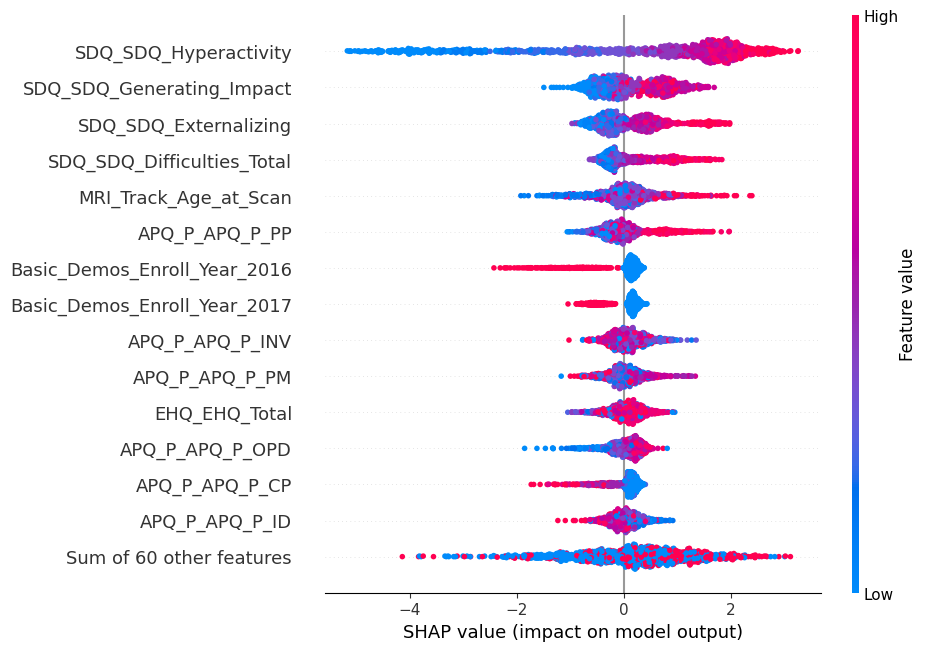

In [13]:
# train a xgboost model
model = xgboost.XGBClassifier().fit(X, y)

# compute SHAP values
explainer = shap.Explainer(model)
shap_values = explainer(X)

# plot the SHAP values to beeswarm plot
shap.plots.beeswarm(shap_values, max_display=15)

### Check most important features for sex

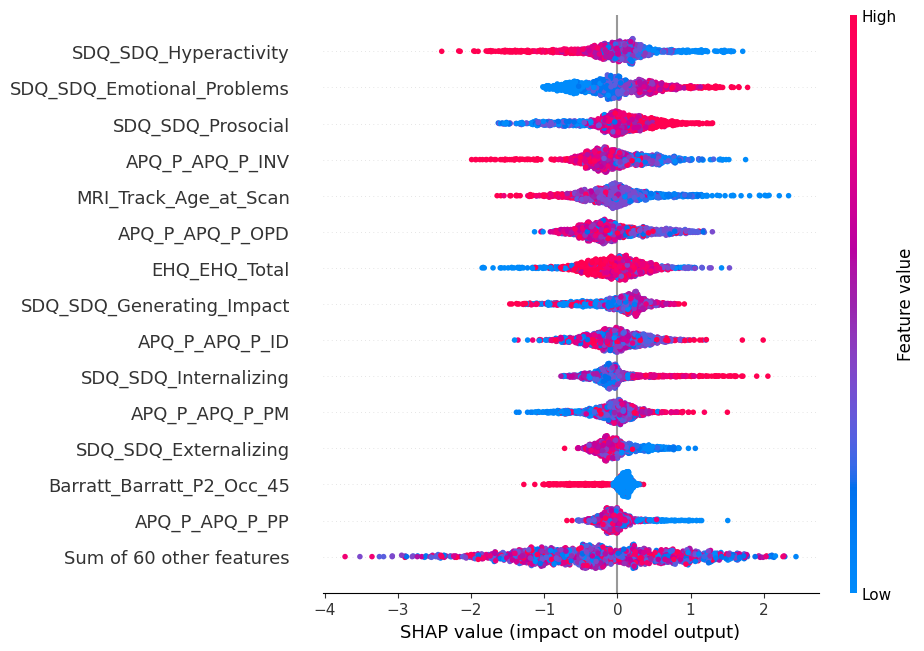

In [15]:
y = train_label.copy()
y = y['Sex_F']

# train a xgboost model
model = xgboost.XGBClassifier().fit(X, y)

# compute SHAP values
explainer = shap.Explainer(model)
shap_values = explainer(X)

# plot the SHAP values to beeswarm plot
shap.plots.beeswarm(shap_values, max_display=15)

## Fit FCM columns and print feature importance

In [16]:
X = train_fcm.copy()
X = X.drop(columns='participant_id')

### Check most important features for ADHD outcome

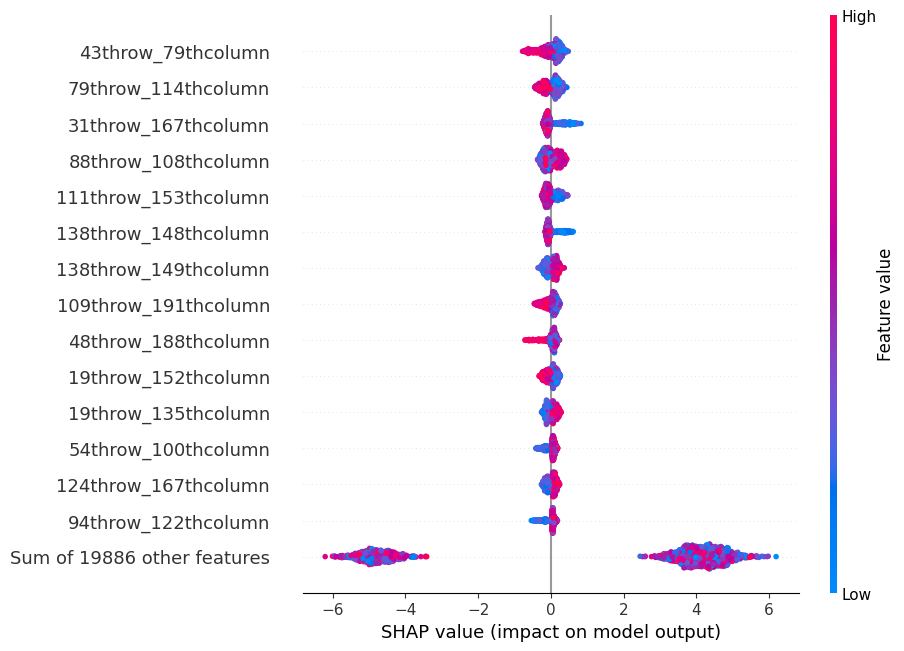

In [17]:
y = train_label.copy()
y = y['ADHD_Outcome']

# train a xgboost model
model = xgboost.XGBClassifier().fit(X, y)

# compute SHAP values
explainer = shap.Explainer(model)
shap_values = explainer(X)

# plot the SHAP values to beeswarm plot
shap.plots.beeswarm(shap_values, max_display=15)

### Check most important features for Sex

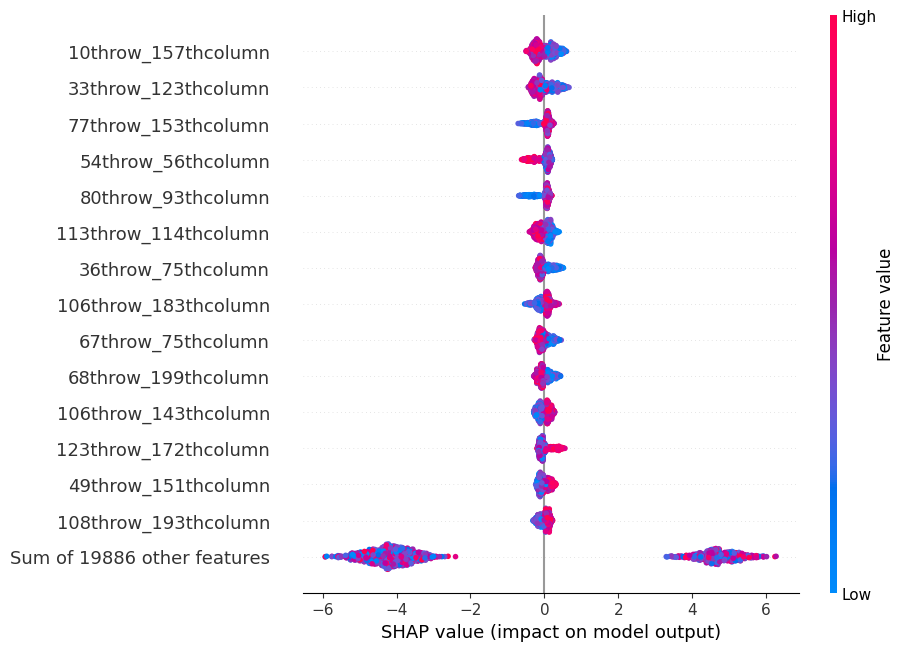

In [18]:
y = train_label.copy()
y = y['Sex_F']

# train a xgboost model
model = xgboost.XGBClassifier().fit(X, y)

# compute SHAP values
explainer = shap.Explainer(model)
shap_values = explainer(X)

# plot the SHAP values to beeswarm plot
shap.plots.beeswarm(shap_values, max_display=15)

## Check all features for importance

In [19]:
X = encoded_df.merge(train_quant, on='participant_id').merge(train_fcm, on='participant_id')
X = X.drop(columns='participant_id')

### Check ADHD

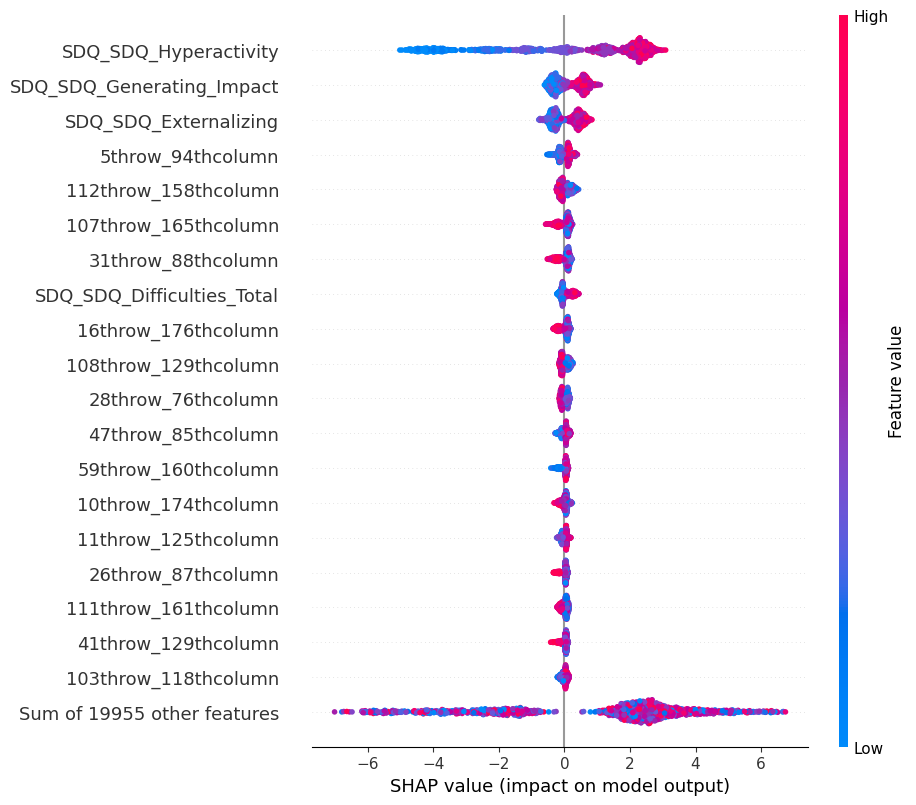

In [20]:
y = train_label.copy()
y = y['ADHD_Outcome']

# train a xgboost model
model = xgboost.XGBClassifier().fit(X, y)

# compute SHAP values
explainer = shap.Explainer(model)
shap_values = explainer(X)

# plot the SHAP values to beeswarm plot
shap.plots.beeswarm(shap_values, max_display=20)

### Check Sex

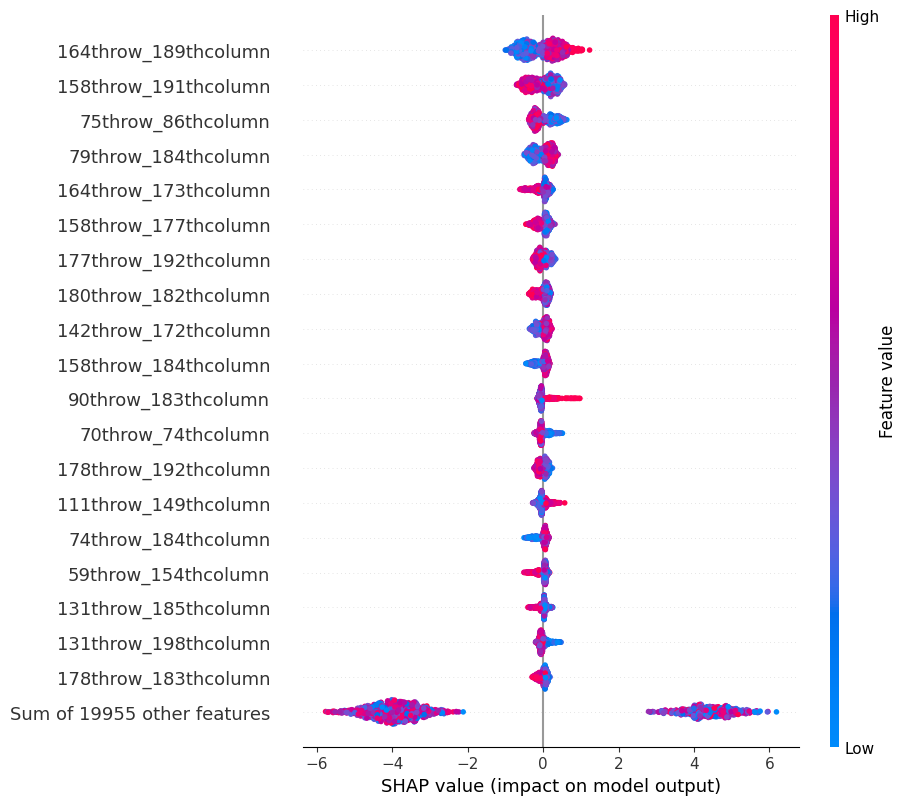

In [21]:
y = train_label.copy()
y = y['Sex_F']

# train a xgboost model
model = xgboost.XGBClassifier().fit(X, y)

# compute SHAP values
explainer = shap.Explainer(model)
shap_values = explainer(X)

# plot the SHAP values to beeswarm plot
shap.plots.beeswarm(shap_values, max_display=20)